### data set -> https://amazon-reviews-2023.github.io/main.html

In [1]:
import json
import pandas as pd

In [14]:
with open('../../data/meta_Electronics.jsonl', 'r') as f:
    first_line = json.loads(f.readline())

In [15]:
first_line

{'main_category': 'All Electronics',
 'title': 'FS-1051 FATSHARK TELEPORTER V3 HEADSET',
 'average_rating': 3.5,
 'rating_number': 6,
 'features': [],
 'description': ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'],
 'price': None,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_US40_.jpg',
   'large': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.

### filter items observed for the first time in 2022 and later

In [18]:
def filter_data(data:dict) -> dict:
    filter = False
    if int(data['details']['Date First Available'][-4:]) < 2022:
        filter = True
    
    return filter

In [19]:
with open('../../data/meta_Electronics.jsonl', 'r') as fp:
    with open('../../data/meta_Electronics_2022_2023.jsonl','a',encoding='utf-8') as fp_out:
        with open('../../data/meta_Electronics_2022_2023_no_date.jsonl','a',encoding='utf-8') as fp_out_no_date:
            i=0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter=filter_data(data)
                    if not filter:
                        json.dump(data, fp_out)
                        fp_out.write('\n')
                        fp_out.flush()
                except:
                        json.dump(data, fp_out_no_date)
                        fp_out_no_date.write('\n')
                        fp_out.flush()
                i += 1
                # if i % 1000 == 0:
                #     print(f"Processed {i} lines")

### split items into "has main category" and "doesn't have main category"

In [20]:
def filter_by_category(data:dict) -> dict:
    filter = False
    if data['main_category']== None:
        filter = True
    
    return filter

In [21]:
with open('../../data/meta_Electronics_2022_2023.jsonl','r') as fp_date:
    with open('../../data/meta_Electronics_2022_2023_has_main_category.jsonl','a',encoding='utf-8') as fp_out_has_main_category:
            with open('../../data/meta_Electronics_2022_2023_no_main_category.jsonl','a',encoding='utf-8') as fp_out_no_main_category:
                  for line in fp_date:
                        data = json.loads(line.strip())
                        if not filter_by_category(data):
                              json.dump(data, fp_out_has_main_category)
                              fp_out_has_main_category.write('\n')
                              fp_out_has_main_category.flush()

                        else:
                              json.dump(data,fp_out_no_main_category)
                              fp_out_no_main_category.write('\n')
                              fp_out_no_main_category.flush()
                        

### Explore Distribution by categories

In [22]:
df = pd.read_json('../../data/meta_Electronics_2022_2023_has_main_category.jsonl', lines=True)

In [23]:
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,Amazon Home,"Outer Space Planets Stickers(50Pcs),Planetary ...",4.5,50,[PROFESSIONAL STICKER SHOP.There are 50 differ...,"[Features:, - Clear picture and exquisite prin...",3.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Watch Before Buying! Huge Waterpro...,Affoto,"[Electronics, Computers & Accessories, Laptop ...","{'Brand': 'Affoto', 'Color': 'Outer Space', 'S...",B0BPLX8B2K,NaN,NaN,NaN
1,Computers,"Gateway 15.6"" FHD Ultra Slim Budget Notebook, ...",4.1,15,"[【Processor】4 Core, 4 Threads, 4MB Cache, up t...","[Processor:, Intel® Pentium® Silver N5030 Proc...",189.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Watch before you order ', 'url': '...",Gateway,"[Electronics, Computers & Accessories, Compute...",{'Standing screen display size': '15.6 Inches'...,B0BYBG1PPD,NaN,NaN,NaN
2,Cell Phones & Accessories,May Chen Compatible with MacBook Pro 16 inch C...,4.5,649,[【 COMPATIBLE WITH 】 Designed to Fits Perfectl...,[May Chen High Quality Plastic Hard Shell Case...,26.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'MOSISO Plastic Hard Shell Compati...,May Chen,"[Electronics, Computers & Accessories, Laptop ...","{'Standing screen display size': '16 Inches', ...",B0822SL7JX,NaN,NaN,NaN
3,All Electronics,"LENTION USB C Docking Station, 10 Gbps USB C&U...",4.4,16,[10-in-1 Docking Station - CB-D65 laptop docki...,[],89.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'LENTION D65 Upgrade Docking Statio...,LENTION,"[Electronics, Computers & Accessories, Laptop ...",{'Package Dimensions': '9.17 x 4.33 x 1.54 inc...,B0BKS1K986,NaN,NaN,NaN
4,All Electronics,1X (No Bluetooth) Eaglewireless Replacement To...,3.0,4,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Eaglewireless,[],{'Package Dimensions': '5.2 x 2.13 x 0.91 inch...,B09MY246CC,NaN,NaN,NaN


<Axes: xlabel='main_category'>

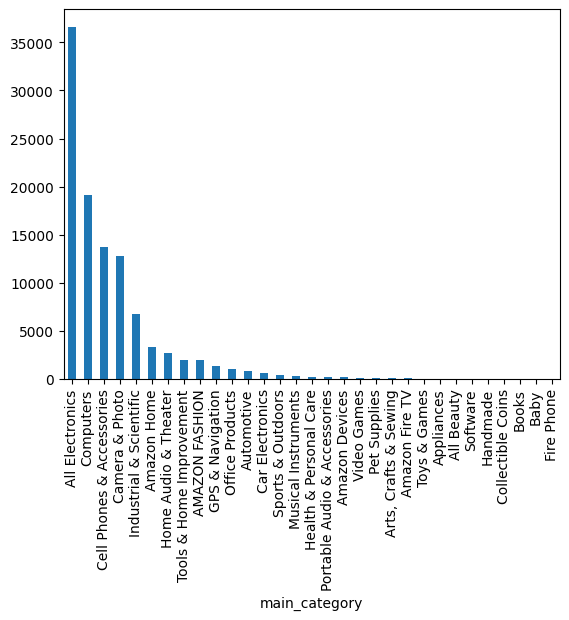

In [24]:
df['main_category'].value_counts().plot(kind='bar')

### Filter out items that have atleast 100 ratings

In [25]:
df_ratings_100 = df[df['rating_number'] >100]

In [26]:
len(df)

103993

In [27]:
len(df_ratings_100)

17162

<Axes: xlabel='main_category'>

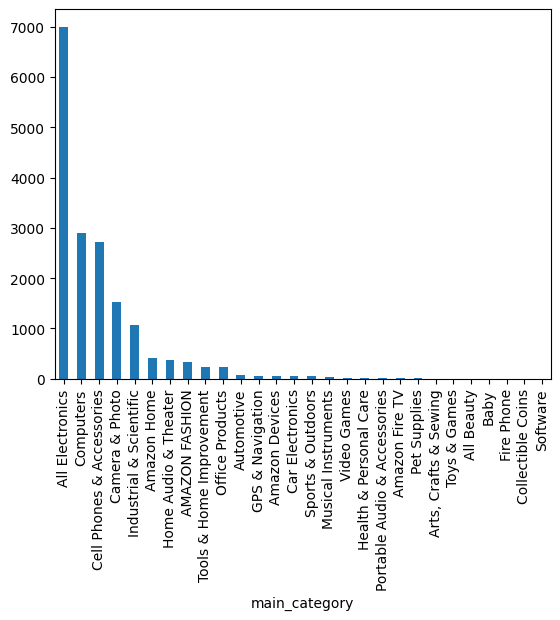

In [28]:
df_ratings_100.value_counts('main_category').plot(kind='bar')

### Explore distribution of ratings

<Axes: ylabel='Frequency'>

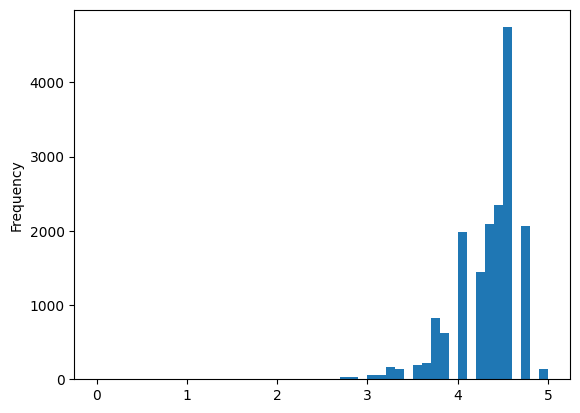

In [29]:
df_ratings_100['average_rating'].plot(kind='hist', bins=50, range=(0,5))

### Sample 1000 items

In [32]:
df_sample_1000 = df.sample(n=1000, random_state=20)

<Axes: ylabel='Frequency'>

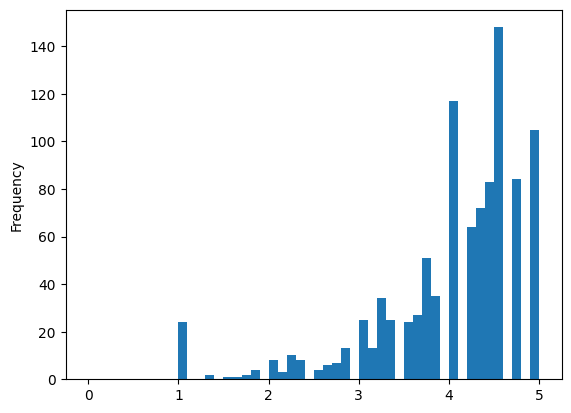

In [33]:
df_sample_1000['average_rating'].plot(kind='hist', bins=50, range=(0,5))

<Axes: ylabel='Frequency'>

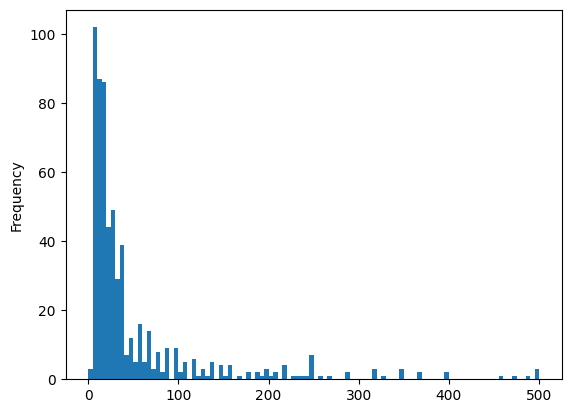

In [35]:
df_sample_1000['price'].plot(kind='hist', bins=100, range=(0,500))

<Axes: xlabel='main_category'>

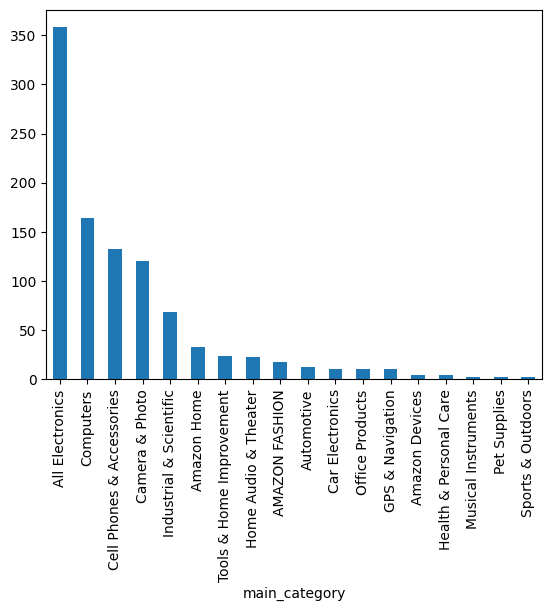

In [36]:
df_sample_1000.value_counts('main_category').plot(kind='bar')

In [37]:
df_ratings_100.to_json('../../data/meta_Electronics_2022_2023_has_main_category_ratings_100.jsonl', orient='records', lines=True)

In [38]:
df_sample_1000.to_json('../../data/meta_Electronics_2022_2023_has_main_category_sample_1000.jsonl', orient='records', lines=True)

### Extract ratings that match sampled data

In [39]:
df_ratings_100=pd.read_json('../../data/meta_Electronics_2022_2023_has_main_category_ratings_100.jsonl', lines=True)
df_sample_1000=pd.read_json('../../data/meta_Electronics_2022_2023_has_main_category_sample_1000.jsonl', lines=True)

In [ ]:
with open('../../data/Electronics.jsonl', 'r') as fp:
    with open('../../data/Electronics_2022_2023_with_category_ratings_100.jsonl','a',encoding='utf-8') as fp_out:
        id_list = set(df_ratings_100['parent_asin'].values)
        i=0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write('\n')
                fp_out.flush()
            i += 1
            if i % 1000 == 0:
                print(f"Processed {i} lines")

Processed 1000 lines
Processed 2000 lines
Processed 3000 lines
Processed 4000 lines
Processed 5000 lines
Processed 6000 lines
Processed 7000 lines
Processed 8000 lines
Processed 9000 lines
Processed 10000 lines
Processed 11000 lines
Processed 12000 lines
Processed 13000 lines
Processed 14000 lines
Processed 15000 lines
Processed 16000 lines
Processed 17000 lines
Processed 18000 lines
Processed 19000 lines
Processed 20000 lines
Processed 21000 lines
Processed 22000 lines
Processed 23000 lines
Processed 24000 lines
Processed 25000 lines
Processed 26000 lines
Processed 27000 lines
Processed 28000 lines
Processed 29000 lines
Processed 30000 lines
Processed 31000 lines
Processed 32000 lines
Processed 33000 lines
Processed 34000 lines
Processed 35000 lines
Processed 36000 lines
Processed 37000 lines
Processed 38000 lines
Processed 39000 lines
Processed 40000 lines
Processed 41000 lines
Processed 42000 lines
Processed 43000 lines
Processed 44000 lines
Processed 45000 lines
Processed 46000 lin

In [ ]:
with open('../../data/Electronics_2022_2023_with_category_ratings_100.jsonl','r') as fp:
    with open('../../data/Electronics_2022_2023_with_category_ratings_100_sample_1000_data.jsonl','a') as fp_out:
        id_list = set(df_sample_1000['parent_asin'].values)
        i=0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write('\n')
                fp_out.flush()
            i += 1
            if i % 1000 == 0:
                print(f"Processed {i} lines")

Processed 1000 lines
Processed 2000 lines
Processed 3000 lines
Processed 4000 lines
Processed 5000 lines
Processed 6000 lines
Processed 7000 lines
Processed 8000 lines
Processed 9000 lines
Processed 10000 lines
Processed 11000 lines
Processed 12000 lines
Processed 13000 lines
Processed 14000 lines
Processed 15000 lines
Processed 16000 lines
Processed 17000 lines
Processed 18000 lines
Processed 19000 lines
Processed 20000 lines
Processed 21000 lines
Processed 22000 lines
Processed 23000 lines
Processed 24000 lines
Processed 25000 lines
Processed 26000 lines
Processed 27000 lines
Processed 28000 lines
Processed 29000 lines
Processed 30000 lines
Processed 31000 lines
Processed 32000 lines
Processed 33000 lines
Processed 34000 lines
Processed 35000 lines
Processed 36000 lines
Processed 37000 lines
Processed 38000 lines
Processed 39000 lines
Processed 40000 lines
Processed 41000 lines
Processed 42000 lines
Processed 43000 lines
Processed 44000 lines
Processed 45000 lines
Processed 46000 lin